<a href="https://colab.research.google.com/github/mib-a/AI-ML-Learning/blob/main/mib-a/AI-ML-Learning/Month-03-Deep-Learning/Module-13/13_Types_of_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent

# Gradient Descent Variants Comparison Matrix

| Aspect / Feature | Batch Gradient Descent (BGD) | Stochastic Gradient Descent (SGD) | Mini-Batch Gradient Descent |
| :--- | :--- | :--- | :--- |
| **Core Definition** | Computes error and gradients using the **entire dataset** before making a single parameter update. | Computes error and gradients using **1 random sample** at a time and updates parameters immediately. | Computes error and gradients using a **small subset (batch)** of samples per update step. |
| **Batch Size ($B$)** | $B = N$ (where $N$ is total dataset size) | $B = 1$ | $1 < B < N$ (typically powers of 2: 32, 64, 128, 256) |
| **Updates per Epoch** | **1 update** per epoch | **$N$ updates** per epoch | **$\lceil N / B \rceil$ updates** per epoch |
| **Workflow / Pseudo-code** | ```python<br>for epoch in range(epochs):<br>    grad = compute_grad(X_all, y_all)<br>    weights -= alpha * grad<br>``` | ```python<br>for epoch in range(epochs):<br>    shuffle(data)<br>    for i in range(N):<br>        grad = compute_grad(x[i], y[i])<br>        weights -= alpha * grad<br>``` | ```python<br>for epoch in range(epochs):<br>    shuffle(data)<br>    for batch in get_batches(data, batch_size):<br>        grad = compute_grad(batch_x, batch_y)<br>        weights -= alpha * grad<br>``` |
| **RAM / Memory Usage** | **High ($O(N)$):** Must load the entire dataset into RAM/VRAM at once. | **Minimal ($O(1)$):** Loads only 1 sample into memory at a time. | **Moderate ($O(B)$):** Loads a batch of size $B$ (e.g., 32 or 64 samples) at a time. |
| **Time per Epoch** | **Slow:** Processes every single row before updating parameters once. | **Slow in execution:** High loop overhead from updating weights $N$ times sequentially. | **Fastest:** Maximizes GPU matrix parallelization while taking frequent updates. |
| **Time to Convergence** | **Slow:** Takes very few steps, but each step is computationally expensive. | **Fast initially, slow near target:** Rapid early progress, but bounces around the minimum. | **Fastest overall:** Combines fast step computation with frequent parameter updates. |
| **Convergence Path** | **Smooth & Deterministic:** Direct line straight down to the nearest minimum. | **Very Noisy & Oscillatory:** Jumps around erratically, but can escape local minima. | **Moderately Smooth:** Minor oscillation, but trends steadily toward the minimum. |
| **GPU / Hardware Utilization** | **Suboptimal for huge data:** Runs out of VRAM. Efficient vectorized matrix operations if data fits. | **Poor:** GPUs are designed for parallel matrix ops; processing 1 row at a time leaves GPU cores idle. | **Optimal:** Fits naturally into modern GPU memory architecture (CUDA / Tensor Cores parallelism). |
| **Suitable Dataset Size** | **Small datasets** ($<10,000$ rows) that easily fit inside RAM. | **Streaming data / Online learning** where data arrives continuously 1 sample at a time. | **Medium to Massive datasets** (thousands to billions of rows). Standard for Deep Learning. |
| **Pros** | • **Stable steps:** Smooth, deterministic path to minimum.<br>• **Simple math:** No randomness or data shuffling needed.<br>• **Guaranteed minimum:** Finds global minimum on convex surfaces. | • **Low memory footprint:** Works on hardware with tiny RAM.<br>• **Escapes local minima:** High gradient noise helps jump out of bad saddle points.<br>• **Great for online learning:** Updates weights on live incoming data. | • **Best balance:** High computational speed + frequent updates.<br>• **Hardware efficient:** Maximizes GPU throughput.<br>• **Reduced gradient variance:** Smoother path than SGD while remaining fast. |
| **Cons** | • **Memory crash risk:** Out-of-memory errors on large datasets.<br>• **Redundant computation:** Computes similar gradients for similar rows.<br>• **Trapped easily:** Can get stuck in bad local minima/saddle points. | • **No parallelization:** Unsuited for modern AI hardware acceleration.<br>• **Noisy trajectory:** High variance makes convergence jumpy.<br>• **Requires learning rate decay:** Won't stay at exact minimum without decreasing $\alpha$. | • **Hyperparameter tuning:** Must pick an additional hyperparameter ($B$).<br>• **Slight gradient variance:** Still has mild noise compared to exact BGD. |

## Generating the Dataset

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate N = 300 samples # num of rows
N = 300
X_raw = 2 * np.random.rand(N, 1) # (300,1)
# print(X_raw)

# True relationship: y = 4 + 3x + noise
y = 4 + 3 * X_raw + np.random.randn(N, 1) # (300,1)
# print(y)
print(X_raw.shape)

# Add bias column (x_0 = 1) -> Matrix shape: (300, 2)
# Math: X = [[1, x^(1)], [1, x^(2)], ..., [1, x^(300)]]
X = np.c_[np.ones((N, 1)), X_raw] # x = np.add(another matrix of 1(300,1) with X_raw (300,1))
# now ur Z = WX (X is including the bias already)
# print(X)

print(f"Dataset X shape: {X.shape} | Target y shape: {y.shape}")

(300, 1)
Dataset X shape: (300, 2) | Target y shape: (300, 1)


The learning rate and epoch value declaring

In [22]:
alpha = 0.05 # learning rate
epochs = 10

### BGD Implementation
- Batch Size: B = N = 300
- Updates/Steps per epoch: 1 update
- Total steps for E epochs: $1\times{E}$
- math per step (update): $\nabla_w J = \frac{1}{N} X^T (Xw - y)$


In [23]:
w_bgd = np.array([[0.0], [0.0]])  # Initial weights
bgd_history = [] # for visualizing purpose

for epoch in range(epochs):
    # 1. Predictions: h_w(X) = X · w (Shape: 300x1)
    y_pred = X.dot(w_bgd)
    # print(y_pred)

    # 2. Residual error: (h_w(X) - y) (Shape: 300x1)
    error = y_pred - y
    # print(error)

    # 3. Cost (MSE): J(w) = (1/2N) * sum(error^2)
    cost = (1 / (2 * N)) * np.sum(error**2) # 1/2 is added for derivative of loss simplification
    # print(cost)
    bgd_history.append(cost)
    # print(bgd_history)

    # 4. Gradient vector: ∇_w J = (1/N) * X^T · error (Shape: 2x1)
    # Computes average gradient across ALL 300 samples
    gradient = (1 / N) * X.T.dot(error)
    # print(gradient)

    # 5. Parameter update: w := w - α * ∇_w J
    w_bgd = w_bgd - alpha * gradient

print(f"BGD Final Weights [w0, w1]: [{w_bgd[0][0]:.3f}, {w_bgd[1][0]:.3f}]")

BGD Final Weights [w0, w1]: [2.209, 2.494]


### SGD Implementation (Stochastic Gradient Descent)
- Batch Size: B = 1
- Updates per epoch: N = 300 updates
- Total Steps/updates: update per epoch * Number of Epochs = $N \times {E}$
- Math per step: $$\nabla_{w} J^{(i)} = (h_{w}(x^{(i)}) - y^{(i)}) \cdot (x^{(i)})^T$$


In [24]:
w_sgd = np.array([[0.0], [0.0]])  # Initial weights
sgd_history = []

for epoch in range(epochs):
  # shuffling: you don't know how to do it yet.
    # Shuffle data indices at the start of every epoch
    indices = np.random.permutation(N)
    X_shuffled = X[indices]
    # print(X_shuffled)
    y_shuffled = y[indices]
    # print(y_shuffled)

    for i in range(N):
        # Extract single sample x_i (Shape: 1x2) and y_i (Shape: 1x1)
        x_i = X_shuffled[i : i + 1]
        # print(x_i)
        y_i = y_shuffled[i : i + 1]

        # 1. Single sample prediction: h_w(x_i) = x_i · w
        y_pred_i = x_i.dot(w_sgd)
        # print(y_pred_i) # -> output = (300*5=1500)

        # 2. Single sample error: (pred - y_i)
        error_i = y_pred_i - y_i

        # 3. Single sample gradient: ∇_w J_i = x_i^T * error_i
        gradient_i = x_i.T.dot(error_i)

        # 4. Parameter update: Immediate update per sample
        w_sgd = w_sgd - alpha * gradient_i

        # Record loss after every sample update to track trajectory
        current_cost = (1 / (2 * N)) * np.sum((X.dot(w_sgd) - y) ** 2)
        sgd_history.append(current_cost)

print(f"SGD Final Weights [w0, w1]: [{w_sgd[0][0]:.3f}, {w_sgd[1][0]:.3f}]")

SGD Final Weights [w0, w1]: [3.919, 3.164]


### Mini-Batch GD Implementation
- Batch Size: B = 32 (always must be exponential of 2 as CPU computes number as $2^N$.
- Updates per Epoch: $\frac{300}{32} = \text{10 updates}$
- Math per step: $$\nabla_w J_{\text{batch}} = \frac{1}{B} X_{\text{batch}}^T (X_{\text{batch}} w - y_{\text{batch}})$$


In [25]:
w_mbgd = np.array([[0.0], [0.0]])  # Initial weights
batch_size = 32
mbgd_history = []

for epoch in range(epochs):
    # Shuffle data at epoch start
    indices = np.random.permutation(N)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, N, batch_size):
        # Extract subset batch of size B=32 (Shape: 32x2 and 32x1)
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]
        B = len(X_batch)

        # 1. Batch prediction: X_batch · w
        y_pred_b = X_batch.dot(w_mbgd)

        # 2. Batch error vector: (pred - y_batch)
        error_b = y_pred_b - y_batch

        # 3. Average gradient over mini-batch: (1/B) * X_batch^T · error_b
        gradient_b = (1 / B) * X_batch.T.dot(error_b)

        # 4. Parameter update per mini-batch
        w_mbgd = w_mbgd - alpha * gradient_b

        # Record loss after each batch update
        current_cost = (1 / (2 * N)) * np.sum((X.dot(w_mbgd) - y) ** 2)
        mbgd_history.append(current_cost)

print(f"Mini-Batch Final Weights [w0, w1]: [{w_mbgd[0][0]:.3f}, {w_mbgd[1][0]:.3f}]")

Mini-Batch Final Weights [w0, w1]: [3.525, 3.373]


# Visualizing the Difference (MatPlotLib)

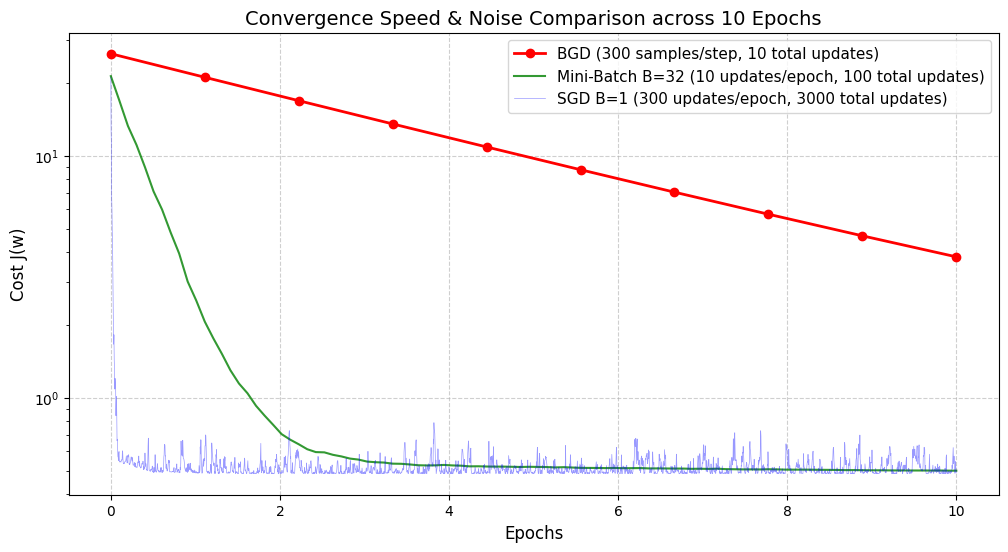

In [28]:
plt.figure(figsize=(12, 6))

# Plot BGD (1 update per epoch = 10 steps total)
plt.plot(
    np.linspace(0, 10, len(bgd_history)),
    bgd_history,
    "r-o",
    linewidth=2,
    label="BGD (300 samples/step, 10 total updates)",
)

# Plot Mini-Batch (10 updates per epoch = 100 steps total)
plt.plot(
    np.linspace(0, 10, len(mbgd_history)),
    mbgd_history,
    "g-",
    linewidth=1.5,
    alpha=0.8,
    label="Mini-Batch B=32 (10 updates/epoch, 100 total updates)",
)

# Plot SGD (300 updates per epoch = 3000 steps total)
plt.plot(
    np.linspace(0, 10, len(sgd_history)),
    sgd_history,
    "b-",
    linewidth=0.5,
    alpha=0.4,
    label="SGD B=1 (300 updates/epoch, 3000 total updates)",
)

plt.title("Convergence Speed & Noise Comparison across 10 Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Cost J(w)", fontsize=12)

plt.yscale("log")  # Log scale highlights differences clearly

plt.grid(True, linestyle="--", alpha = 0.6)
plt.legend(fontsize=11)
plt.show()